<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [1]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-09-08 01:38:23--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  45.3MB/s    in 4.0s    

2026-09-08 01:38:28 (38.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [3]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [4]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [5]:
##Write your code here
# Ordered age categories
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older',
    'Prefer not to say'
]

def order_age(df, col='Age'):
    "Convert Age column into ordered categorical variables"
    df[col] = pd.Categorical(df[col], categories=age_order, ordered=True)
    return df

def explode_multiselect(df, column, separator=';'):
    'Multi select explode function'
    df_clean = df.copy()
    df_clean = df_clean.dropna(subset=[column])
    df_clean[column] = df_clean[column].str.split(separator)
    df_clean = df_clean.explode(column)
    df_clean[column] = df_clean[column].str.strip()
    return df_clean

def clean_comp(df, col='ConvertedCompYearly'):
    'Remove extreme outliers from comp using the IQR'
    df_clean = df.copy()
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    df_clean = df_clean[df_clean[col] <= upper]
    return df_clean

def median_by_age(df, cols):
    'compute median values by ordered age groups'
    temp = df.groupby('Age')[cols].median()
    temp = temp.loc[age_order] # for correct visual order
    return temp

df1 = order_age(df.copy())
df_comp = clean_comp(df1)
test = median_by_age(df_comp, ['JobSatPoints_6', 'JobSatPoints_7', 'JobSat'])
test

/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/178574315.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('Age')[cols].median()


,JobSatPoints_6,JobSatPoints_7,JobSat
Age,,,
Under 18 years old,10.0,5.0,8.0
18-24 years old,20.0,20.0,7.0
25-34 years old,20.0,15.0,7.0
35-44 years old,20.0,15.0,7.0
45-54 years old,20.0,15.0,7.0
55-64 years old,20.0,20.0,8.0
65 years or older,22.5,15.0,8.0
Prefer not to say,10.0,20.0,8.0


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/178574315.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('Age')[cols].median()


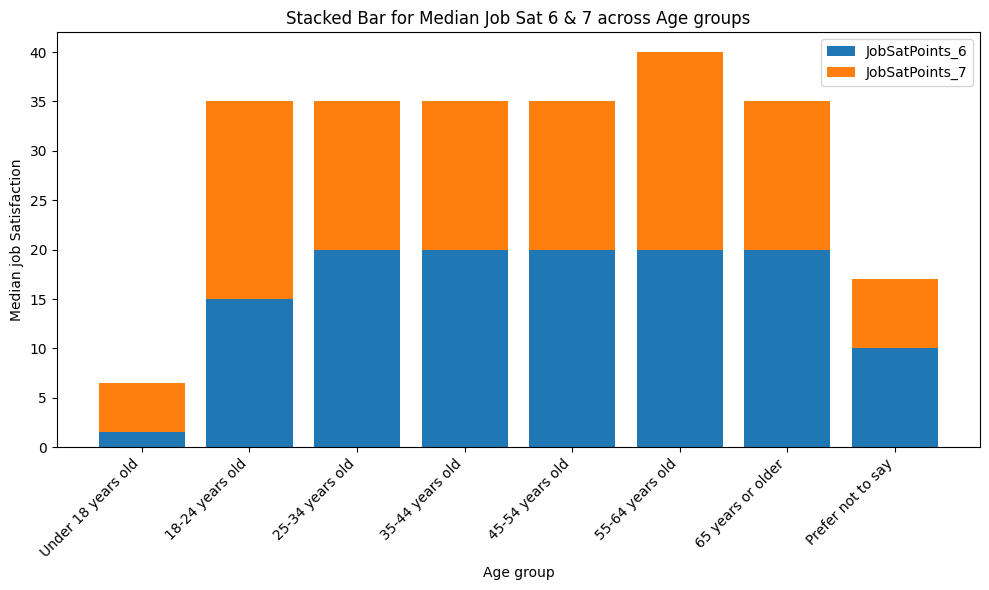

In [6]:
##Write your code here
# Task 1 completion
df_age = order_age(df.copy())
jobsat_by_age = median_by_age(df_age, ['JobSatPoints_6', 'JobSatPoints_7'])

jobsat_by_age = jobsat_by_age.dropna(how='all')

plt.figure(figsize=(10, 6))
x= range(len(jobsat_by_age))

plt.bar(x, jobsat_by_age['JobSatPoints_6'], label='JobSatPoints_6')
# second bar layered on top
plt.bar(x, jobsat_by_age['JobSatPoints_7'], bottom=jobsat_by_age['JobSatPoints_6'], label='JobSatPoints_7')

plt.title('Stacked Bar for Median Job Sat 6 & 7 across Age groups')
plt.xticks(x, jobsat_by_age.index, rotation=45, ha='right')
plt.xlabel('Age group')
plt.ylabel('Median job Satisfaction')
plt.legend()
plt.tight_layout()
plt.show()


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


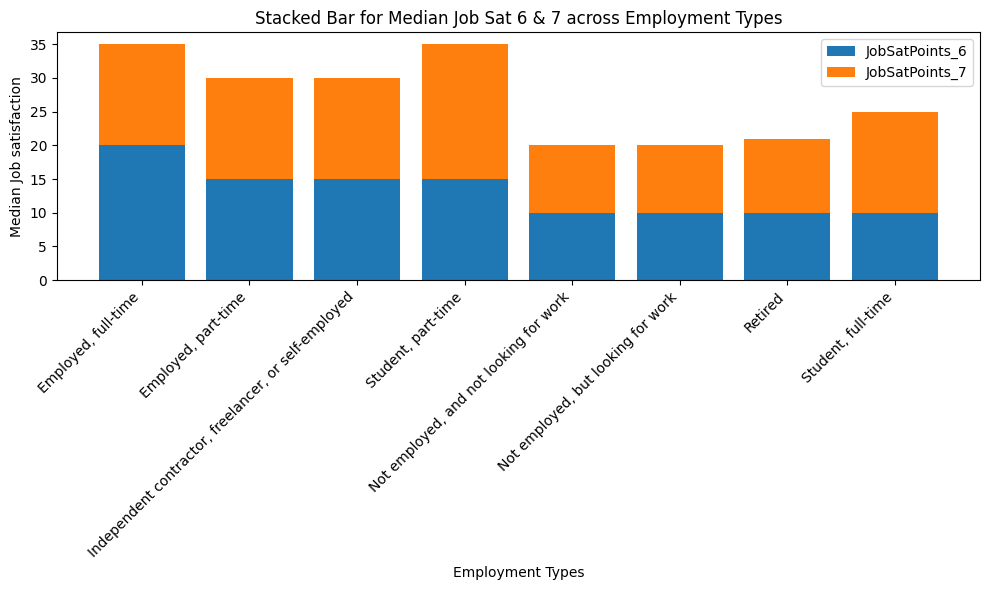

In [ ]:
##Write your code here
df_emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna(subset='Employment')

df_emp_explode = explode_multiselect(df_emp, 'Employment')
jobsat_by_emp = df_emp_explode.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()
jobsat_by_emp = jobsat_by_emp.dropna(how='all')

# Sorting for nicer visuals
jobsat_by_emp = jobsat_by_emp.sort_values('JobSatPoints_6', ascending=False)

plt.figure(figsize=(10, 6))

x = range(len(jobsat_by_emp))

plt.bar(x, jobsat_by_emp['JobSatPoints_6'], label='JobSatPoints_6')
plt.bar(x, jobsat_by_emp['JobSatPoints_7'], bottom=jobsat_by_emp['JobSatPoints_6'], label='JobSatPoints_7')

plt.title('Stacked Bar for Median Job Sat 6 & 7 across Employment Types')
plt.xticks(x, jobsat_by_emp.index, rotation=45, ha='right')
plt.xlabel('Employment Types')
plt.ylabel('Median Job satisfaction')
plt.legend()
plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


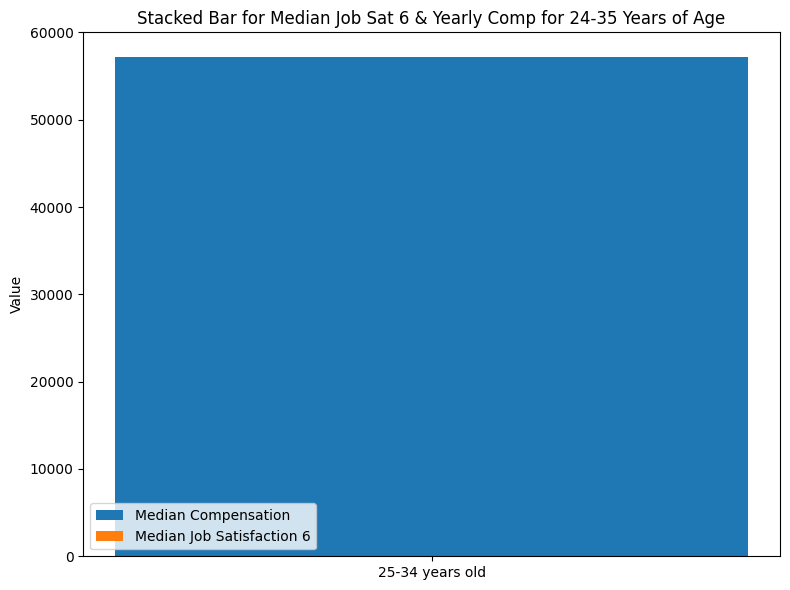

In [8]:
##Write your code here
# Filter age group using 25 - 34 instead
df_2534 = df[df['Age'] == '25-34 years old'].copy()

df_2534_clean = clean_comp(df_2534)

median_comp = df_2534_clean['ConvertedCompYearly'].median()
median_sat = df_2534_clean['JobSatPoints_6'].median()

# dataframe for visualization
df_CCJS = pd.DataFrame({
    'Key': ['Median Compensation', 'Median Job Satisfaction 6'],
    'Value': [median_comp, median_sat]
})

plt.figure(figsize=(8, 6))

plt.bar(['25-34 years old'], [median_comp], label='Median Compensation')
plt.bar(['25-34 years old'], [median_sat], bottom=[median_comp], label='Median Job Satisfaction 6')

plt.title('Stacked Bar for Median Job Sat 6 & Yearly Comp for 24-35 Years of Age')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/1469852556.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_comp_age = df_clean_comp.groupby('Age')['ConvertedCompYearly'].median()
/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/1469852556.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_js_age = df_clean_comp.groupby('Age')['JobSat'].median()


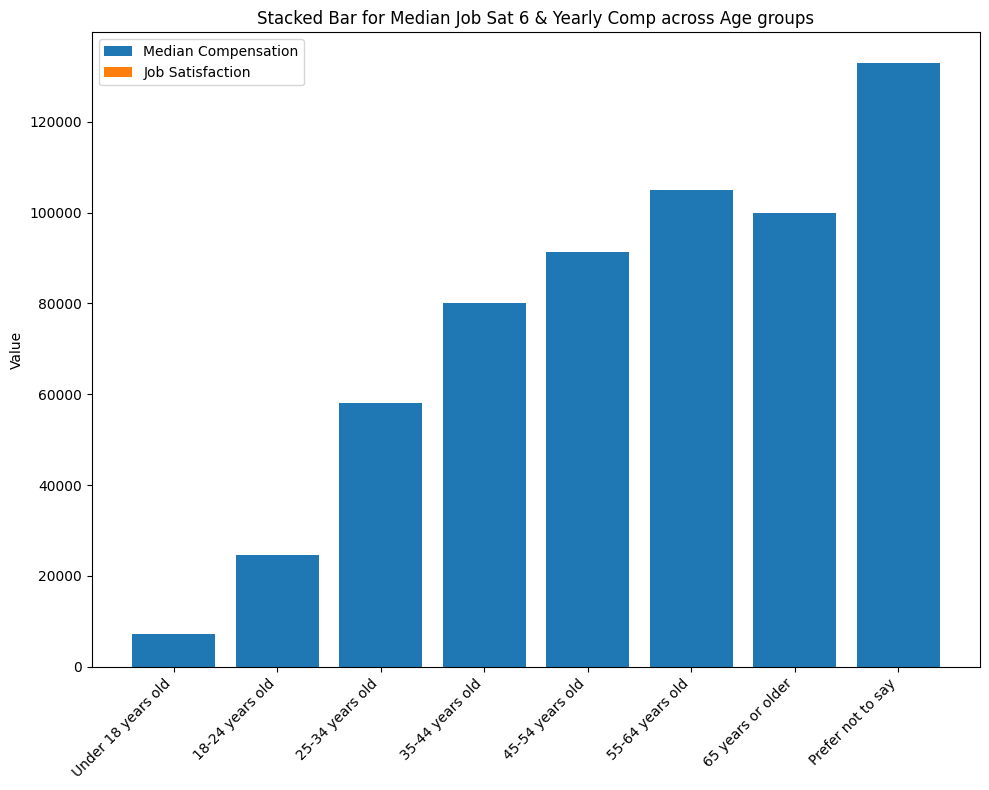

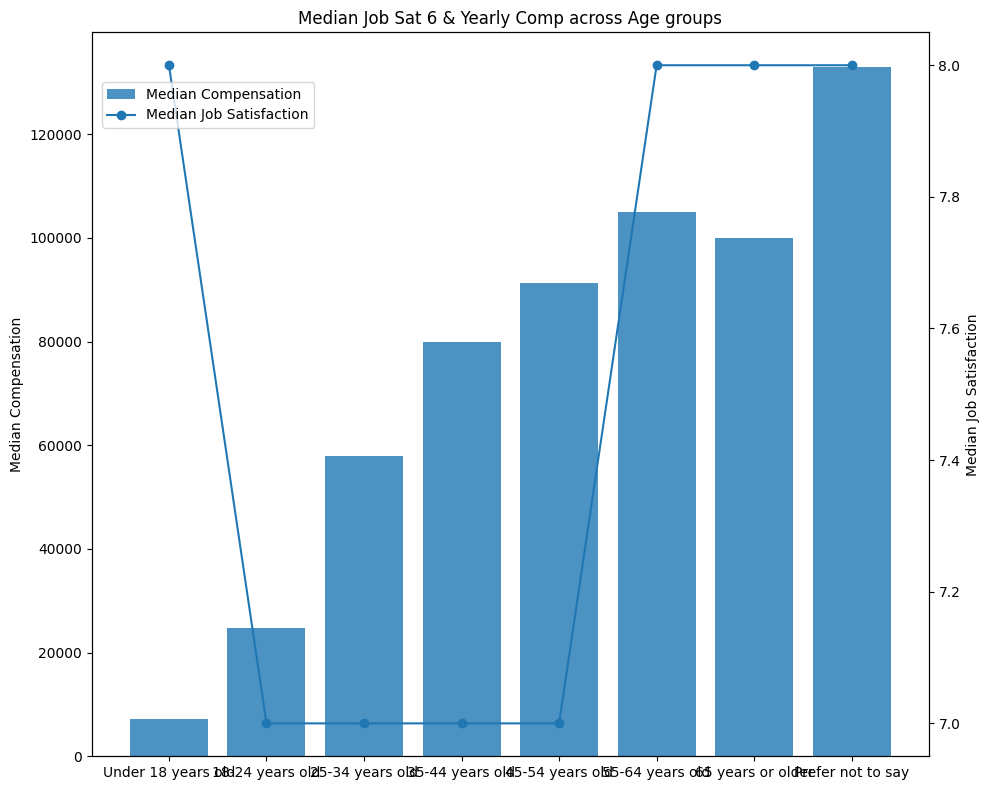

In [9]:
##Write your code here
df_clean_comp = clean_comp(order_age(df.copy()))

median_comp_age = df_clean_comp.groupby('Age')['ConvertedCompYearly'].median()
median_js_age = df_clean_comp.groupby('Age')['JobSat'].median()

#Align both series to same age order
median_comp_age = median_comp_age.loc[age_order]
median_js_age = median_js_age.loc[age_order]

# remove NaN values for both
valid = ~(median_js_age.isna() & median_comp_age.isna())
median_comp_age = median_comp_age[valid]
median_js_age = median_js_age[valid]

plt.figure(figsize=(10, 8))
x = range(len(median_comp_age))

plt.bar(x, median_comp_age, label='Median Compensation')
plt.bar(x, median_js_age, bottom=median_comp_age, label='Job Satisfaction')

plt.title('Stacked Bar for Median Job Sat 6 & Yearly Comp across Age groups')
plt.xticks(x, median_comp_age.index, rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show() # Not a great presentation of data

fig, ax1 = plt.subplots(figsize=(10, 8))
ages = median_comp_age.index
x =range(len(ages))

# Bar for Compensation visuals
ax1.bar(x, median_comp_age, label='Median Compensation', alpha=0.8)
ax1.set_ylabel("Median Compensation")
ax1.tick_params(axis='y')

# line graph for job sat
ax2 = ax1.twinx()
ax2.plot(x, median_js_age, marker='o', label='Median Job Satisfaction')
ax2.set_ylabel('Median Job Satisfaction')
ax2.tick_params(axis='y')

plt.title('Median Job Sat 6 & Yearly Comp across Age groups')
plt.xticks(x, ages, rotation=45, ha='right')
fig.tight_layout()
# Build combined legend
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
handles, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/166234635.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  db_count = df_db.groupby(['Age', 'DatabaseWantToWorkWith']).size().reset_index(name='Count')


<Figure size 1000x800 with 0 Axes>

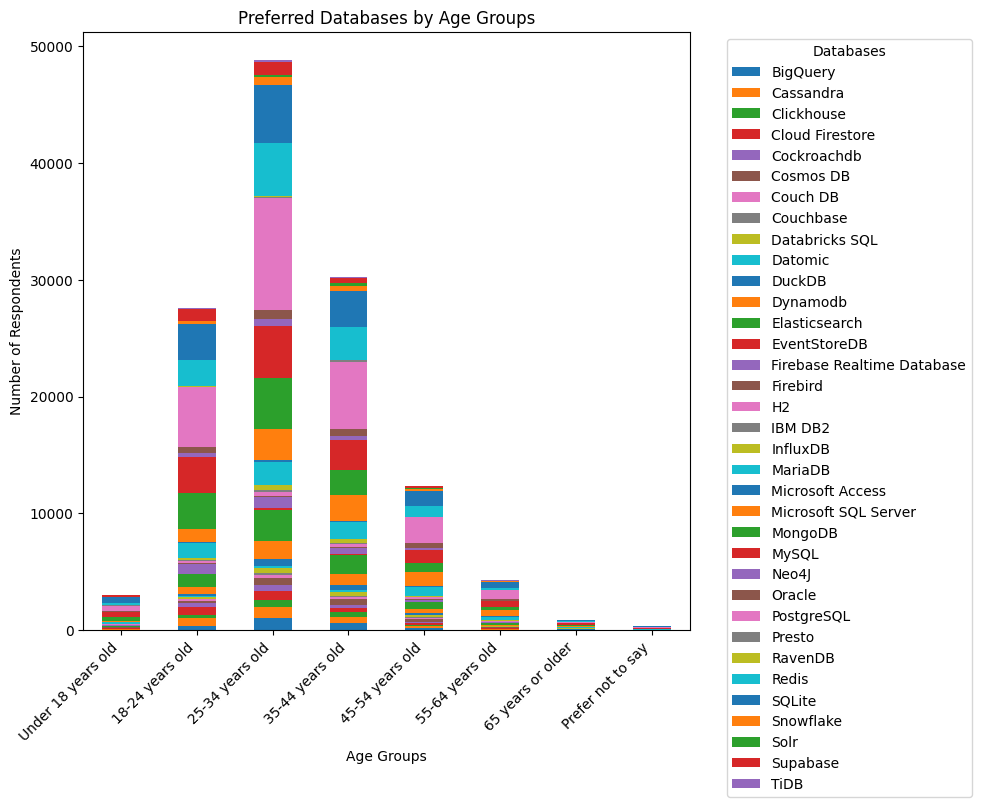

/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/166234635.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  db_counts = filtered.groupby(['Age', 'DatabaseWantToWorkWith']).size().reset_index(name='Count')


<Figure size 1000x800 with 0 Axes>

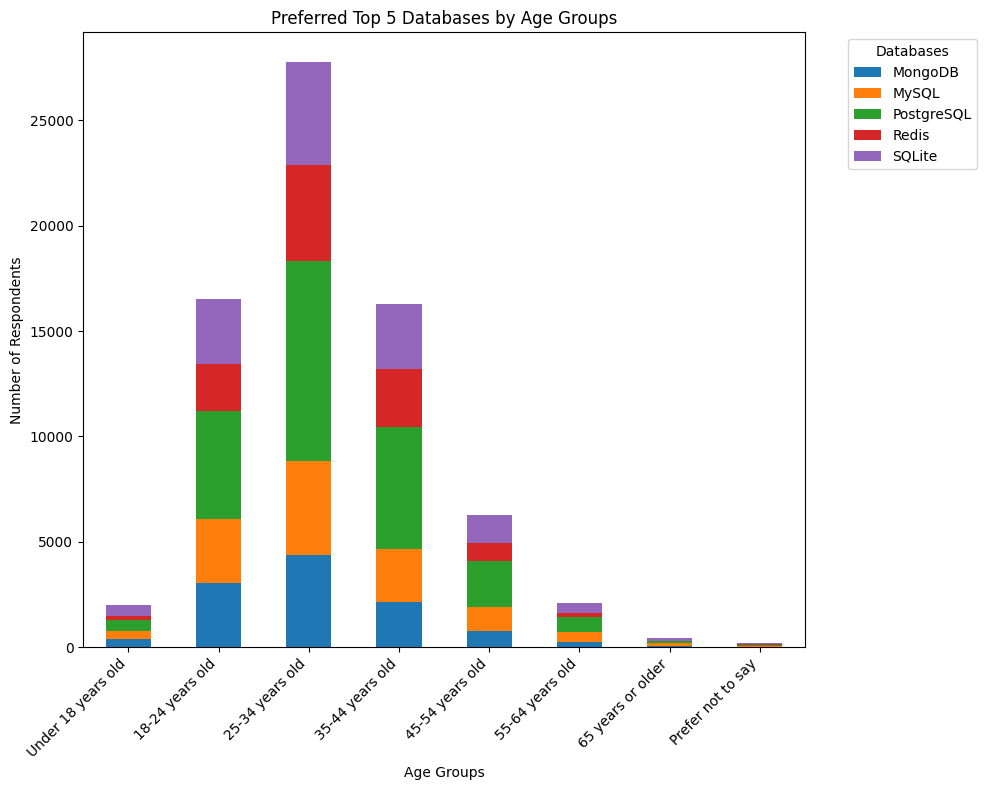

In [22]:
##Write your code here
# use df_age from above
df_db = df_age[['Age', 'DatabaseWantToWorkWith']].dropna()

#explode
df_db = explode_multiselect(df_db, 'DatabaseWantToWorkWith')

db_count = df_db.groupby(['Age', 'DatabaseWantToWorkWith']).size().reset_index(name='Count')

# pivot to wide format for stacked bar chart
db_pivot = db_count.pivot(index='Age', columns='DatabaseWantToWorkWith', values='Count').fillna(0)
# keep only age categories that exist
db_pivot = db_pivot.loc[age_order].dropna(how='all')

plt.figure(figsize=(10, 8))
db_pivot.plot(kind='bar', stacked=True, figsize=(10,8))

plt.title('Preferred Databases by Age Groups')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Groups')
plt.ylabel('Number of Respondents')
plt.legend(title='Databases', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#get only top 5 databases
top_5_db = df_db['DatabaseWantToWorkWith'].value_counts().head(5).index
filtered = df_db[df_db['DatabaseWantToWorkWith'].isin(top_5_db)]


db_counts = filtered.groupby(['Age', 'DatabaseWantToWorkWith']).size().reset_index(name='Count')

# pivot to wide format for stacked bar chart
db_pivoted = db_counts.pivot(index='Age', columns='DatabaseWantToWorkWith', values='Count').fillna(0)
# keep only age categories that exist
db_pivoted = db_pivoted.loc[age_order].dropna(how='all')

plt.figure(figsize=(10, 8))
db_pivoted.plot(kind='bar', stacked=True, figsize=(10,8))

plt.title('Preferred Top 5 Databases by Age Groups')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Groups')
plt.ylabel('Number of Respondents')
plt.legend(title='Databases', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


<Figure size 1000x800 with 0 Axes>

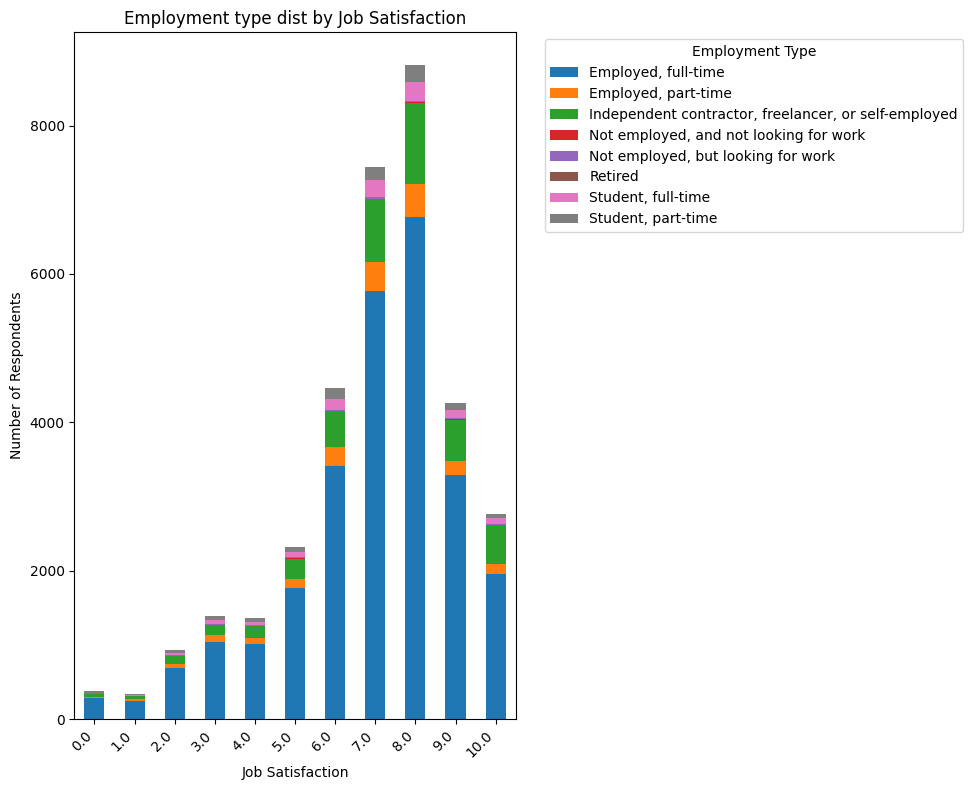

In [24]:
##Write your code here
df_emp_sat = df[['Employment', 'JobSat']].dropna()

df_emp_sat = explode_multiselect(df_emp_sat, 'Employment')

# Group count of respondents persatisfaction levels
emp_sat_count = df_emp_sat.groupby(['JobSat', 'Employment']).size().reset_index(name='Count')

emp_sat_pivot = emp_sat_count.pivot(index='JobSat', columns='Employment', values='Count').fillna(0)

#sort satisfaction values for better visuals
emp_sat_pivot = emp_sat_pivot.sort_index()

plt.figure(figsize=(10, 8))
emp_sat_pivot.plot(kind='bar', stacked=True, figsize=(10,8))
plt.title('Employment type dist by Job Satisfaction')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Job Satisfaction')
plt.ylabel('Number of Respondents')
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/1742976076.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  db_lang_count = df_lang.groupby(['Age', 'LanguageAdmired']).size().reset_index(name='Count')


<Figure size 1000x800 with 0 Axes>

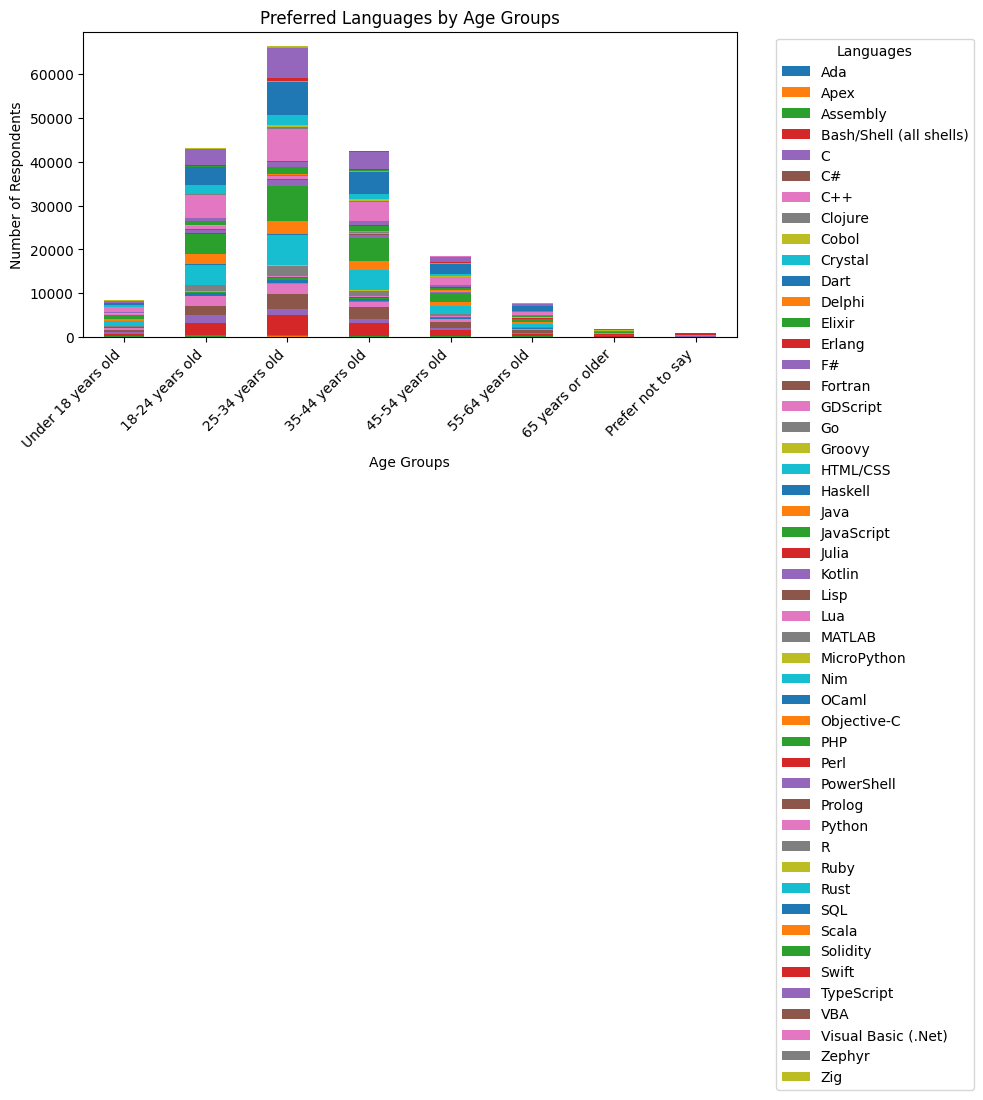

/var/folders/0l/pvtw36_j26v20v1h4xc53l940000gn/T/ipykernel_50167/1742976076.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  db_counts1 = filtered1.groupby(['Age', 'LanguageAdmired']).size().reset_index(name='Count')


<Figure size 1000x800 with 0 Axes>

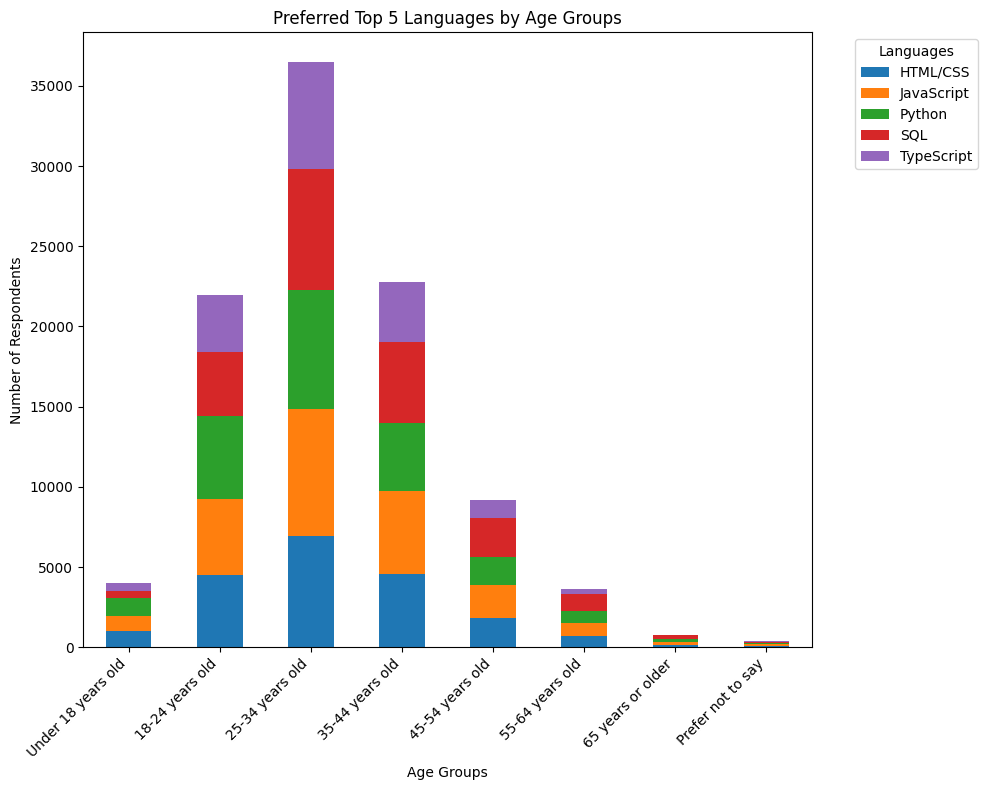

In [25]:
##Write your code here
df_lang = df_age[['Age', 'LanguageAdmired']].dropna()

#explode
df_lang = explode_multiselect(df_lang, 'LanguageAdmired')

db_lang_count = df_lang.groupby(['Age', 'LanguageAdmired']).size().reset_index(name='Count')

# pivot to wide format for stacked bar chart
db_pivots = db_lang_count.pivot(index='Age', columns='LanguageAdmired', values='Count').fillna(0)
# keep only age categories that exist
db_pivots = db_pivots.loc[age_order].dropna(how='all')

plt.figure(figsize=(10, 8))
db_pivots.plot(kind='bar', stacked=True, figsize=(10,8))

plt.title('Preferred Languages by Age Groups')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Groups')
plt.ylabel('Number of Respondents')
plt.legend(title='Languages', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#get only top 5 databases
top_5_lang = df_lang['LanguageAdmired'].value_counts().head(5).index
filtered1 = df_lang[df_lang['LanguageAdmired'].isin(top_5_lang)]


db_counts1 = filtered1.groupby(['Age', 'LanguageAdmired']).size().reset_index(name='Count')

# pivot to wide format for stacked bar chart
db_pivoted1 = db_counts1.pivot(index='Age', columns='LanguageAdmired', values='Count').fillna(0)
# keep only age categories that exist
db_pivoted1 = db_pivoted1.loc[age_order].dropna(how='all')

plt.figure(figsize=(10, 8))
db_pivoted1.plot(kind='bar', stacked=True, figsize=(10,8))

plt.title('Preferred Top 5 Languages by Age Groups')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Age Groups')
plt.ylabel('Number of Respondents')
plt.legend(title='Languages', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


<Figure size 1000x800 with 0 Axes>

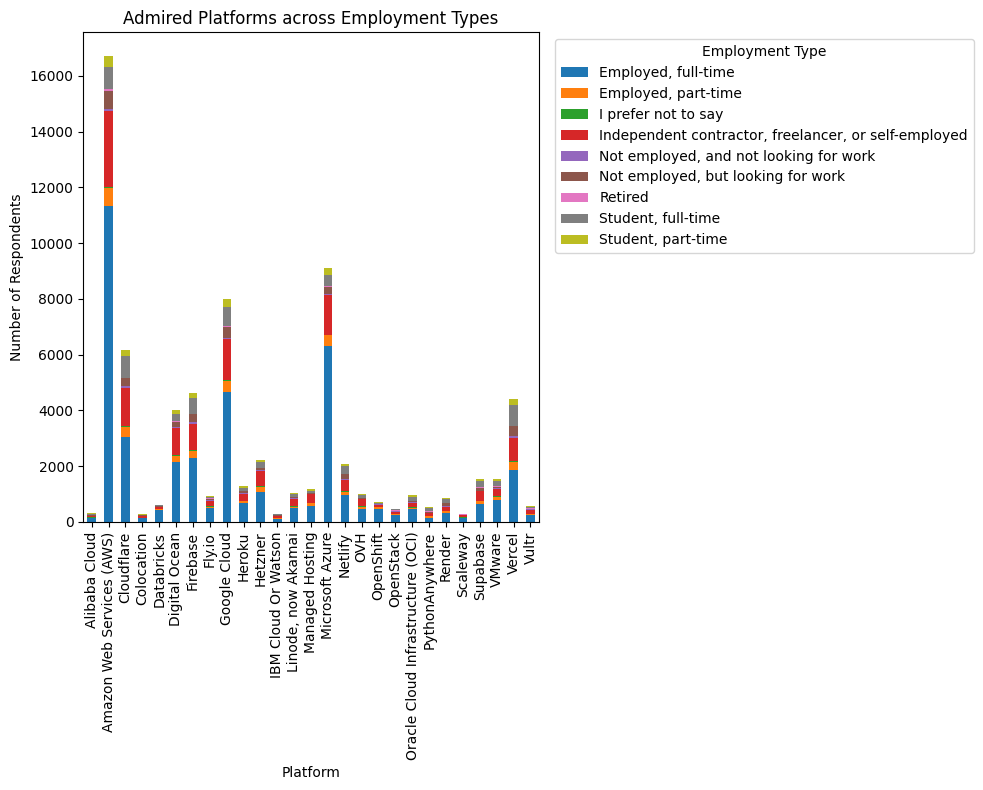

In [30]:
##Write your code here
df_pa = df[['Employment', 'PlatformAdmired']].dropna()

df_pa = explode_multiselect(df_pa, 'Employment')
df_pa = explode_multiselect(df_pa, 'PlatformAdmired')

#Count each admired platform across each employment type
pa_count = (
    df_pa.groupby(['PlatformAdmired', 'Employment'])
    .size()
    .reset_index(name='Count')
)

# pivot rows= platform, columns=employment
pa_pivot = (
    pa_count.pivot(index='PlatformAdmired', columns='Employment', values='Count')
    .fillna(0)
)
plt.figure(figsize=(10, 8))

pa_pivot.plot(kind='bar', stacked=True, figsize=(10, 8))
plt.title('Admired Platforms across Employment Types')
plt.xticks(rotation=90)
plt.xlabel('Platform')
plt.ylabel('Number of Respondents')
plt.legend(title='Employment Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
